In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]

In [7]:
import copy
import torch

# 1. Define the Thermodynamic Grid
# We define tuples of (learning_rate, batch_size)
# The resulting temperatures (lr/B) will span several orders of magnitude.
grid = [
    (0.001, 1024),
    (0.001, 512),
    (0.001, 256),  # T = 0.000003 (Deep Freeze)
    (0.001, 200),  # T = 0.000005
    (0.001, 128),  # T = 0.000008
    (0.0025, 128),  # T = 0.000016
    (0.005, 128),  # T = 0.000039
    (0.0075, 128), # T = 0.000059
    (0.01,  128),  # T = 0.000078
    (0.01,  64),   # T = 0.000156
    (0.025,  64),   # T = 0.000312
    (0.05,  64),   # T = 0.000781
    (0.1,   64),   # T = 0.001562
    (0.1,   32),   # T = 0.003125
    (0.2,   32),   # T = 0.006250
    (0.2,   16),   # T = 0.012500 (Scorching Hot - might cause loss spikes!)
]

seeds = [0, 1, 2, 3, 4]

# Dictionary to store the final trained weights mapped to (temperature, seed)
results_dict = {}

print("Starting Thermodynamic Sweep...")

for seed in seeds:
    print(f"\n#################### SEED {seed} ####################")
    torch.manual_seed(seed)
    np.random.seed(seed)

    for lr, batch_size in grid:
        # Calculate effective temperature
        temperature = lr / batch_size
        
        print(f"\n==================================================")
        print(f"Training Regime: T = {temperature:.6f} | lr={lr}, B={batch_size} | Seed={seed}")
        print(f"==================================================")
        
        # Run the training function we defined previously
        # We use 500 epochs to ensure the "diffusion phase" has plenty of time to settle
        trained_model = train_model(
            dataset=dataset, 
            input_dim=input_dim, 
            lr=lr, 
            batch_size=batch_size, 
            epochs=500
        )
        
        # Extract the final weights (w*)
        final_weights = copy.deepcopy(trained_model.state_dict())
        
        # Store in our dictionary keyed by (temperature, seed)
        results_dict[(temperature, seed)] = final_weights

print("\nSweep Complete! All models stored in memory.")

# --- LIFESAVER STEP: Save to disk ---
# This prevents you from losing 2 hours of training if your laptop dies or the kernel crashes.
torch.save(results_dict, "thermodynamic_sweep_results.pth")
print("Results safely saved to 'thermodynamic_sweep_results.pth'")


Starting Thermodynamic Sweep...

#################### SEED 0 ####################

Training Regime: T = 0.000001 | lr=0.001, B=1024 | Seed=0
Epoch [100/500] | Loss: 0.0086 | Temp (lr/B): 0.00000
Epoch [200/500] | Loss: 0.0041 | Temp (lr/B): 0.00000
Epoch [300/500] | Loss: 0.0027 | Temp (lr/B): 0.00000
Epoch [400/500] | Loss: 0.0020 | Temp (lr/B): 0.00000
Epoch [500/500] | Loss: 0.0015 | Temp (lr/B): 0.00000

Training Regime: T = 0.000002 | lr=0.001, B=512 | Seed=0
Epoch [100/500] | Loss: 0.0043 | Temp (lr/B): 0.00000
Epoch [200/500] | Loss: 0.0020 | Temp (lr/B): 0.00000
Epoch [300/500] | Loss: 0.0013 | Temp (lr/B): 0.00000
Epoch [400/500] | Loss: 0.0010 | Temp (lr/B): 0.00000
Epoch [500/500] | Loss: 0.0008 | Temp (lr/B): 0.00000

Training Regime: T = 0.000004 | lr=0.001, B=256 | Seed=0
Epoch [100/500] | Loss: 0.0021 | Temp (lr/B): 0.00000
Epoch [200/500] | Loss: 0.0010 | Temp (lr/B): 0.00000
Epoch [300/500] | Loss: 0.0007 | Temp (lr/B): 0.00000
Epoch [400/500] | Loss: 0.0005 | Temp (lr

Loading saved models...
Calculating Local Entropy for each temperature regime and seed...
T = 0.000001 | Seed=0 | Local Entropy = -0.0109
T = 0.000001 | Seed=1 | Local Entropy = -0.0118
T = 0.000001 | Seed=2 | Local Entropy = -0.0123
T = 0.000001 | Seed=3 | Local Entropy = -0.0108
T = 0.000001 | Seed=4 | Local Entropy = -0.0134
T = 0.000002 | Seed=0 | Local Entropy = -0.0063
T = 0.000002 | Seed=1 | Local Entropy = -0.0056
T = 0.000002 | Seed=2 | Local Entropy = -0.0066
T = 0.000002 | Seed=3 | Local Entropy = -0.0056
T = 0.000002 | Seed=4 | Local Entropy = -0.0061
T = 0.000004 | Seed=0 | Local Entropy = -0.0034
T = 0.000004 | Seed=1 | Local Entropy = -0.0032
T = 0.000004 | Seed=2 | Local Entropy = -0.0031
T = 0.000004 | Seed=3 | Local Entropy = -0.0038
T = 0.000004 | Seed=4 | Local Entropy = -0.0032
T = 0.000005 | Seed=0 | Local Entropy = -0.0024
T = 0.000005 | Seed=1 | Local Entropy = -0.0023
T = 0.000005 | Seed=2 | Local Entropy = -0.0031
T = 0.000005 | Seed=3 | Local Entropy = -0.002

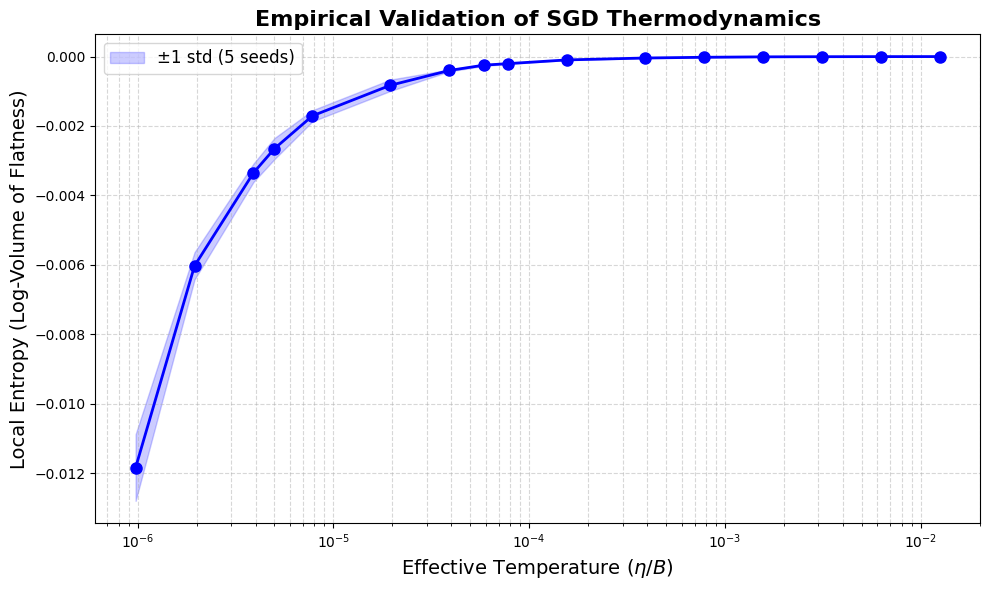

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy
import math

# --- 1. The Perturbation Function ---
def compute_local_entropy(base_model, dataloader, criterion, gamma=1000.0, num_samples=100, perturbation_scale=0.03):
    """
    Approximates local free-entropy F(x; gamma) = log E[exp(-f(x') - gamma/2 ||x-x'||^2)]
    using Monte Carlo perturbations around x.
    """
    base_model.eval()
    energies = []
    
    # Extract the base weights into a flat vector (easier to perturb)
    base_weights = torch.nn.utils.parameters_to_vector(base_model.parameters())
    
    # We don't need gradients for this evaluation phase
    with torch.no_grad():
        for _ in range(num_samples):
            # 1. Generate Gaussian noise
            noise = torch.randn_like(base_weights) * perturbation_scale
            perturbed_weights = base_weights + noise
            
            # 2. Load the perturbed weights into a temporary model
            temp_model = copy.deepcopy(base_model)
            torch.nn.utils.vector_to_parameters(perturbed_weights, temp_model.parameters())
            
            # 3. Calculate the loss of this perturbed model over the whole dataset
            total_loss = 0.0
            total_count = 0
            for batch_X, batch_y in dataloader:
                outputs = temp_model(batch_X)
                batch_loss = criterion(outputs, batch_y)
                batch_size = len(batch_y)
                total_loss += batch_loss.item() * batch_size
                total_count += batch_size
            
            avg_loss = total_loss / max(total_count, 1)

            # 4. Add the quadratic confinement energy term (gamma/2)||x-x'||^2
            delta = perturbed_weights - base_weights
            quad_penalty = 0.5 * gamma * torch.dot(delta, delta).item()
            total_energy = avg_loss + quad_penalty
            energies.append(total_energy)
            
    # 5. Compute local free-entropy using numerically stable LogSumExp
    # log(1/N * sum(exp(-E_i))) = logsumexp(-E) - log(N)
    energies_tensor = torch.tensor(energies)
    local_entropy = torch.logsumexp(-energies_tensor, dim=0) - math.log(num_samples)
    
    return local_entropy.item()

# --- 2. The Evaluation Loop ---
print("Loading saved models...")
results_dict = torch.load("thermodynamic_sweep_results.pth")
dataloader = DataLoader(dataset, batch_size=256, shuffle=False) # Large batch for fast evaluation
criterion = nn.CrossEntropyLoss()

seeds = [0, 1, 2, 3, 4]

# Collect all unique temperatures
all_temperatures = sorted(set(temp for temp, seed in results_dict.keys()))

# Dict: temperature -> list of entropies (one per seed)
entropy_by_temp = {temp: [] for temp in all_temperatures}

print("Calculating Local Entropy for each temperature regime and seed...")
for (temp, seed), state_dict in sorted(results_dict.items()):
    model = FlatMLP(input_dim=100)
    model.load_state_dict(state_dict)
    
    entropy = compute_local_entropy(model, dataloader, criterion, gamma=1000.0, num_samples=100, perturbation_scale=0.03)
    entropy_by_temp[temp].append(entropy)
    print(f"T = {temp:.6f} | Seed={seed} | Local Entropy = {entropy:.4f}")

# Average across seeds
temperatures = all_temperatures
mean_entropies = [np.mean(entropy_by_temp[t]) for t in temperatures]
std_entropies  = [np.std(entropy_by_temp[t])  for t in temperatures]

# --- 3. The Grand Finale: Plotting ---
plt.figure(figsize=(10, 6))

plt.semilogx(temperatures, mean_entropies, marker='o', linestyle='-', color='b', markersize=8, linewidth=2)
plt.fill_between(
    temperatures,
    [m - s for m, s in zip(mean_entropies, std_entropies)],
    [m + s for m, s in zip(mean_entropies, std_entropies)],
    alpha=0.2, color='b', label='±1 std (5 seeds)'
)

plt.title("Empirical Validation of Local Free-Entropy vs Temperature", fontsize=16, fontweight='bold')
plt.xlabel(r"Effective Temperature $(\eta / B)$", fontsize=14)
plt.ylabel(r"Local Free-Entropy $F(x;\gamma)$ (up to const.)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Local_Entropy_vs_Temperature.png", dpi=300)
plt.show()


In [1]:
def compute_loss_at_radius(base_model, dataloader, criterion, radius, num_directions=10):
    """
    Computes the average loss exactly at a distance 'r' from the minimum.
    This acts as the empirical proxy for the Franz-Parisi distance profile.
    """
    base_model.eval()
    losses = []
    
    # Extract the base weights
    base_weights = torch.nn.utils.parameters_to_vector(base_model.parameters())
    
    with torch.no_grad():
        for _ in range(num_directions):
            # 1. Generate a random direction vector
            direction = torch.randn_like(base_weights)
            
            # 2. Normalize it to have a length exactly equal to 1
            direction = direction / torch.norm(direction)
            
            # 3. Multiply by the exact scalar radius 'r'
            step_vector = direction * radius
            perturbed_weights = base_weights + step_vector
            
            # 4. Load the perturbed weights and calculate loss
            temp_model = copy.deepcopy(base_model)
            torch.nn.utils.vector_to_parameters(perturbed_weights, temp_model.parameters())
            
            total_loss = 0
            for batch_X, batch_y in dataloader:
                outputs = temp_model(batch_X)
                total_loss += criterion(outputs, batch_y).item()
            
            avg_loss = total_loss / len(dataloader)
            losses.append(avg_loss)
            
    # 5. Simply average the losses (no logsumexp here!)
    return sum(losses) / len(losses)

In [2]:
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import copy

print("Loading saved models...")
results_dict = torch.load("thermodynamic_sweep_results.pth")

# 1. Define the radii to sweep
radii = np.arange(0.0, 3.1, 0.2)  # From 0 to 3 in steps of 0.2

# Collect all unique temperatures (skip the 2 coldest as before)
all_temperatures = sorted(set(temp for temp, seed in results_dict.keys()))
temperatures = all_temperatures[2:]

seeds = [0, 1, 2, 3, 4]

# Dict: temperature -> array of shape (num_seeds, num_radii)
all_losses_by_temp = {temp: [] for temp in temperatures}

print(f"Found {len(temperatures)} temperature regimes. Computing loss landscapes across {len(seeds)} seeds...")

# 2. Evaluate every model across all radii
for temp in temperatures:
    print(f"\n--- Evaluating Temperature: T = {temp:.6f} ---")
    for seed in seeds:
        key = (temp, seed)
        if key not in results_dict:
            print(f"  Seed {seed} not found, skipping.")
            continue
        model = FlatMLP(input_dim=100)
        model.load_state_dict(results_dict[key])
        
        seed_losses = []
        for r in radii:
            loss_r = compute_loss_at_radius(model, dataloader, criterion, radius=r, num_directions=30)
            seed_losses.append(loss_r)
            print(f"  Seed={seed} | Radius {r:.1f} -> Avg Loss = {loss_r:.4f}")
        
        all_losses_by_temp[temp].append(seed_losses)

# 3. Generate the Thesis-Ready Plot
plt.figure(figsize=(12, 8))

norm = plt.matplotlib.colors.LogNorm(vmin=min(temperatures), vmax=max(temperatures))
cmap = cm.get_cmap('coolwarm')

for temp in temperatures:
    color = cmap(norm(temp))
    losses_matrix = np.array(all_losses_by_temp[temp])  # shape: (num_seeds, num_radii)
    mean_losses = losses_matrix.mean(axis=0)
    std_losses  = losses_matrix.std(axis=0)
    
    plt.plot(radii, mean_losses, linestyle='-', color=color,
             linewidth=2.5, alpha=0.9, label=f'T = {temp:.6f}')
    plt.fill_between(radii, mean_losses - std_losses, mean_losses + std_losses,
                     color=color, alpha=0.15)

# Professional formatting
plt.title("Evolution of Landscape Geometry with SGD Temperature", fontsize=16, fontweight='bold')
plt.xlabel("Perturbation Radius (r)", fontsize=14)
plt.ylabel("Average Expected Loss", fontsize=14)

plt.legend(title="Effective Temp $(\eta/B)$", title_fontsize='13', fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Full_Loss_vs_Radius_Evolution.png", dpi=300)
plt.show()


Loading saved models...
Found 14 temperature regimes. Computing loss landscapes across 5 seeds...

--- Evaluating Temperature: T = 0.000004 ---


NameError: name 'FlatMLP' is not defined